# kash_dataset — Prep & Cleaning

**Input layout (your Kaggle dataset):**
```
/kaggle/input/kash-dataset/
    neutral/      img001.jpg  img002.jpg  ...
    confused/     img003.jpg  ...
    disgust/      ...
    happy/        ...
    sad/          ...
```

**What this notebook does:**
1. Scans folders → builds `labels.csv`
2. Detects & crops face from each image (OpenCV Haar cascade)
3. Rejects: no face found, blurry image, face too small
4. Resizes to 224×224, saves cleaned images
5. Creates `master_split.csv` (train/val split, EmpathBot label IDs)

**Output** (saved to `/kaggle/working/kash_clean/`):
```
kash_clean/
    images/          ← cropped + resized images
    labels.csv       ← all images with label + split
    rejected.csv     ← images that failed quality checks
    summary.png      ← class distribution chart
```

## 1. Setup

In [22]:
import subprocess, sys
# opencv-python is pre-installed on Kaggle; this is a no-op if already present
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'opencv-python-headless'], check=False)

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split

print(f'OpenCV {cv2.__version__}')

OpenCV 4.13.0


## 2. Config

In [23]:
# ── Input ─────────────────────────────────────────────────────────────────────
RAW_DIR = Path('/kaggle/input/kash-dataset')   # <── your dataset slug

RAW_DIR = Path('/Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/data/kash_dataset') 

# ── Output ────────────────────────────────────────────────────────────────────
OUT_DIR    = Path('/Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/data/kash_clean')
IMG_OUT    = OUT_DIR / 'images'
IMG_OUT.mkdir(parents=True, exist_ok=True)

# ── Folder name → EmpathBot eb_label mapping ──────────────────────────────────
# Adjust if your folder names differ.
FOLDER_TO_LABEL = {
    'neutral':      0,
    'trust_relief': 1,
    'sadness':      2,
    'sad':          2,   # alias
    'fear_anxiety': 3,
    'fear':         3,   # alias
    'confusion':    4,
    'confused':     4,   # alias
    'distrust':     5,
    'disgust':      5,   # alias
    'anger':        5,   # alias
    'angry':        5,   # alias
    'happy':        1,   # alias → trust_relief
    'happiness':    1,
}

CLASS_NAMES = {
    0: 'neutral', 1: 'trust_relief', 2: 'sadness',
    3: 'fear_anxiety', 4: 'confusion', 5: 'distrust',
}

# ── Image quality thresholds ──────────────────────────────────────────────────
OUT_SIZE        = 224     # final image size (pixels)
MIN_FACE_PX     = 48      # reject if detected face is smaller than this (px)
BLUR_THRESHOLD  = 80.0    # Laplacian variance — below this = too blurry
FACE_PADDING    = 0.25    # fraction of face size to add as padding around the crop

# ── Train / val split ─────────────────────────────────────────────────────────
VAL_FRACTION = 0.20
RANDOM_SEED  = 42

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print('Config ready.')
print(f'Input : {RAW_DIR}')
print(f'Output: {OUT_DIR}')

Config ready.
Input : /Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/data/kash_dataset
Output: /Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/data/kash_clean


## 3. Scan folders → raw image list

In [24]:
raw_rows = []
skipped_folders = []

for folder in sorted(RAW_DIR.iterdir()):
    if not folder.is_dir():
        continue
    folder_name = folder.name.lower()
    if folder_name not in FOLDER_TO_LABEL:
        skipped_folders.append(folder.name)
        continue
    label_id = FOLDER_TO_LABEL[folder_name]
    for img_path in sorted(folder.iterdir()):
        if img_path.suffix.lower() in IMG_EXTS:
            raw_rows.append({
                'src_path':   str(img_path),
                'folder':     folder.name,
                'eb_label':   label_id,
                'label_name': CLASS_NAMES[label_id],
            })

raw_df = pd.DataFrame(raw_rows)
print(f'Found {len(raw_df):,} images across {raw_df["folder"].nunique()} folders')
if skipped_folders:
    print(f'⚠️  Skipped folders (not in FOLDER_TO_LABEL): {skipped_folders}')

print('\nPer-folder counts:')
print(raw_df.groupby(['folder', 'label_name', 'eb_label']).size().rename('count').to_string())

Found 176 images across 5 folders

Per-folder counts:
folder    label_name    eb_label
confused  confusion     4           52
disgust   distrust      5            9
happy     trust_relief  1           48
neutral   neutral       0           10
sad       sadness       2           57


## 4. Face detection & cropping

Uses OpenCV's Haar cascade (pre-installed on Kaggle, no GPU needed).  
Each image goes through:
1. Face detection — if no face found, image is rejected
2. Size check — face must be at least `MIN_FACE_PX × MIN_FACE_PX`
3. Blur check — Laplacian variance must exceed `BLUR_THRESHOLD`
4. Crop with padding → resize to `OUT_SIZE × OUT_SIZE`

In [25]:
%pip install "mediapipe==0.9.3.0"

ERROR: Could not find a version that satisfies the requirement mediapipe==0.9.3.0 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32, 0.10.33, 0.10.35)
ERROR: No matching distribution found for mediapipe==0.9.3.0
Note: you may need to restart the kernel to use updated packages.


In [26]:
# # Option A: MediaPipe face detection

# from mediapipe.python.solutions import face_detection as mp_face_detection

# mp_face = mp_face_detection.FaceDetection(model_selection=1, min_detection_confidence=0.5)

# def detect_and_crop(img_path: str, padding: float, min_face_px: int):
#     """Returns (cropped_rgb_array, reject_reason). reject_reason is None on success."""
#     img_bgr = cv2.imread(img_path)
#     if img_bgr is None:
#         return None, 'unreadable'

#     img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
#     H, W = img_rgb.shape[:2]

#     results = mp_face.process(img_rgb)
#     if not results.detections:
#         return None, 'no_face'

#     det = max(results.detections, key=lambda d: d.score[0])
#     bb = det.location_data.relative_bounding_box
#     x1 = int(bb.xmin * W)
#     y1 = int(bb.ymin * H)
#     fw = int(bb.width * W)
#     fh = int(bb.height * H)

#     if fw < min_face_px or fh < min_face_px:
#         return None, 'face_too_small'

#     pad_x = int(fw * padding)
#     pad_y = int(fh * padding)
#     cx1 = max(0, x1 - pad_x)
#     cy1 = max(0, y1 - pad_y)
#     cx2 = min(W, x1 + fw + pad_x)
#     cy2 = min(H, y1 + fh + pad_y)

#     return img_rgb[cy1:cy2, cx1:cx2], None


# def blur_score(img_rgb: np.ndarray) -> float:
#     gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
#     return cv2.Laplacian(gray, cv2.CV_64F).var()


# print('Functions ready.')

In [27]:
# Option B: No cropping (just resize)
# Replace detect_and_crop with a no-op that just reads and returns the full image,
# and remove the no_face/face_too_small rejection reasons:


def detect_and_crop(img_path: str, padding: float, min_face_px: int):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None, 'unreadable'
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), None

In [28]:
# Download Haar cascade XML (bundled with opencv)
CASCADE_PATH = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(CASCADE_PATH)
print(f'Cascade loaded: {CASCADE_PATH}')
#     """
#     Returns (cropped_rgb_array, reject_reason).
#     reject_reason is None on success.
#     """
#     img_bgr = cv2.imread(img_path)
#     if img_bgr is None:
#         return None, 'unreadable'

#     gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

#     # Detect faces — try normal then flipped for robustness
#     faces = face_cascade.detectMultiScale(
#         gray, scaleFactor=1.1, minNeighbors=5, minSize=(min_face_px, min_face_px)
#     )
#     if len(faces) == 0:
#         # retry with looser params
#         faces = face_cascade.detectMultiScale(
#             gray, scaleFactor=1.05, minNeighbors=3, minSize=(min_face_px // 2, min_face_px // 2)
#         )
#     if len(faces) == 0:
#         return None, 'no_face'

#     # Pick the largest face
#     x, y, w, h = max(faces, key=lambda f: f[2] * f[3])

#     if w < min_face_px or h < min_face_px:
#         return None, 'face_too_small'

#     # Add padding
#     pad_x = int(w * padding)
#     pad_y = int(h * padding)
#     H, W  = img_bgr.shape[:2]
#     x1 = max(0, x - pad_x)
#     y1 = max(0, y - pad_y)
#     x2 = min(W, x + w + pad_x)
#     y2 = min(H, y + h + pad_y)

#     crop_bgr = img_bgr[y1:y2, x1:x2]
#     crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
#     return crop_rgb, None


def blur_score(img_rgb: np.ndarray) -> float:
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


print('Functions ready.')

Cascade loaded: /Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/.venv/lib/python3.12/site-packages/cv2/data/haarcascade_frontalface_default.xml
Functions ready.


In [29]:
accepted_rows = []
rejected_rows = []

for i, row in raw_df.iterrows():
    src   = row['src_path']
    label = row['eb_label']

    # Face detection + crop
    crop, reason = detect_and_crop(src, FACE_PADDING, MIN_FACE_PX)
    if crop is None:
        rejected_rows.append({**row, 'reason': reason})
        continue

    # Blur check
    score = blur_score(crop)
    if score < BLUR_THRESHOLD:
        rejected_rows.append({**row, 'reason': f'blurry ({score:.1f})'})
        continue

    # Resize and save
    out_name = f'{label}_{Path(src).stem}_{i:05d}.jpg'
    out_path = IMG_OUT / out_name
    pil_img  = Image.fromarray(crop).resize((OUT_SIZE, OUT_SIZE), Image.LANCZOS)
    pil_img.save(out_path, quality=95)

    accepted_rows.append({
        'filename':   out_name,
        'path':       str(out_path),
        'eb_label':   label,
        'label_name': CLASS_NAMES[label],
        'blur_score': round(score, 1),
        'src_path':   src,
    })

    if (i + 1) % 50 == 0:
        print(f'  processed {i+1}/{len(raw_df)} ...', end='\r')

accepted_df = pd.DataFrame(accepted_rows)
rejected_df = pd.DataFrame(rejected_rows)

print(f'\n\nDone.')
print(f'  Accepted : {len(accepted_df):>4}')
print(f'  Rejected : {len(rejected_df):>4}')
if len(rejected_df):
    print('\n  Rejection breakdown:')
    print(rejected_df['reason'].str.replace(r'blurry.*', 'blurry', regex=True).value_counts().to_string())

  processed 100/176 ...

Done.
  Accepted :  118
  Rejected :   58

  Rejection breakdown:
reason
blurry    58


## 5. Visualise — sample crops per class

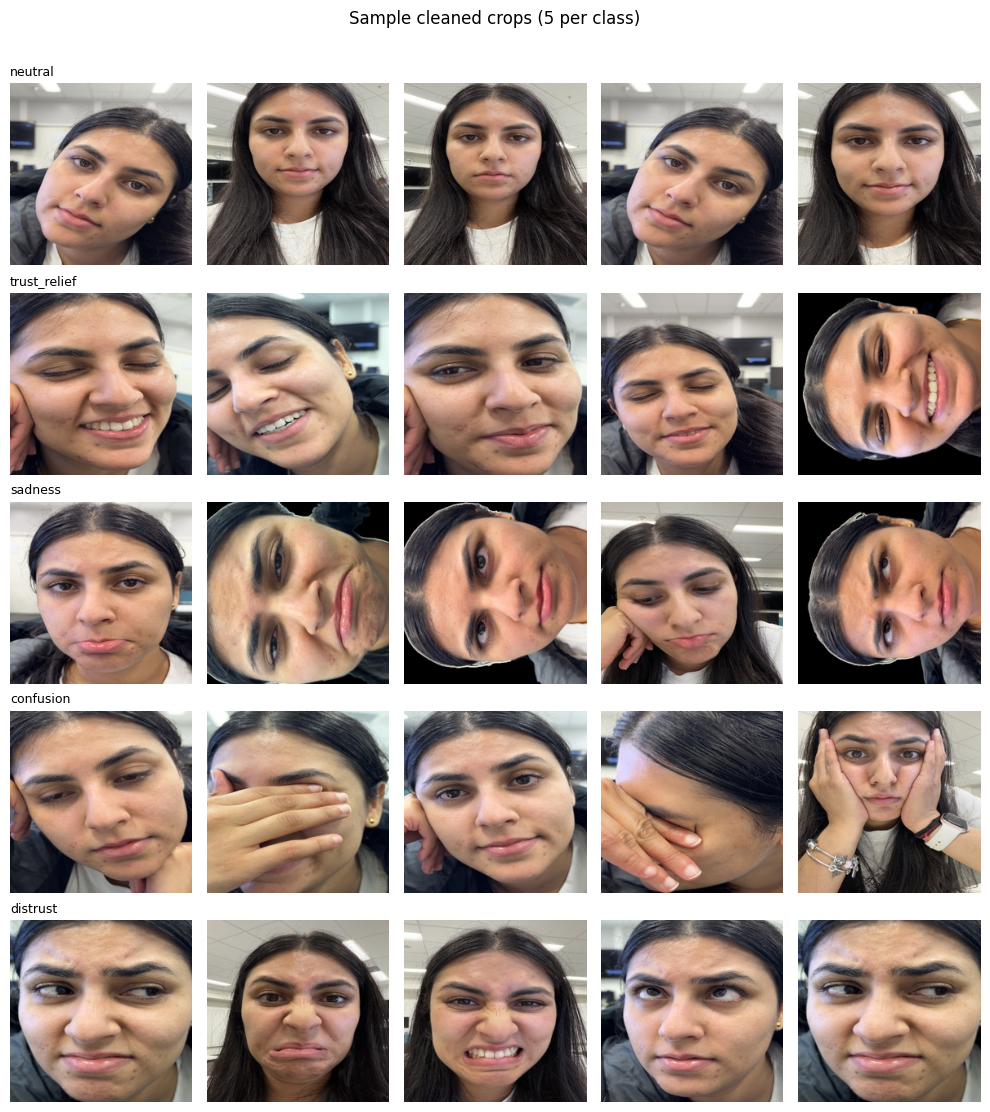

In [30]:
labels_present = sorted(accepted_df['eb_label'].unique())
n_cols = 5
fig, axes = plt.subplots(len(labels_present), n_cols, figsize=(n_cols * 2, len(labels_present) * 2.2))
if len(labels_present) == 1:
    axes = [axes]

for row_idx, lbl in enumerate(labels_present):
    subset = accepted_df[accepted_df['eb_label'] == lbl].sample(
        min(n_cols, len(accepted_df[accepted_df['eb_label'] == lbl])), random_state=0
    )
    for col_idx in range(n_cols):
        ax = axes[row_idx][col_idx]
        ax.axis('off')
        if col_idx < len(subset):
            img = Image.open(subset.iloc[col_idx]['path'])
            ax.imshow(img)
            if col_idx == 0:
                ax.set_title(CLASS_NAMES[lbl], fontsize=9, loc='left')

plt.suptitle('Sample cleaned crops (5 per class)', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'sample_crops.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Train / val split → labels.csv

In [31]:
# # Stratified split so each class has proportional val samples
# if len(accepted_df) < 10:
#     raise RuntimeError('Too few accepted images to split. Check face detection params.')

# train_idx, val_idx = train_test_split(
#     accepted_df.index,
#     test_size=VAL_FRACTION,
#     stratify=accepted_df['eb_label'],
#     random_state=RANDOM_SEED,
# )

# accepted_df['split'] = 'train'
# accepted_df.loc[val_idx, 'split'] = 'val'

# # Save CSVs
# labels_csv   = OUT_DIR / 'labels.csv'
# rejected_csv = OUT_DIR / 'rejected.csv'

# accepted_df[['filename', 'path', 'eb_label', 'label_name', 'split', 'blur_score']].to_csv(
#     labels_csv, index=False
# )
# rejected_df.to_csv(rejected_csv, index=False)

# print(f'labels.csv  saved → {labels_csv}  ({len(accepted_df)} rows)')
# print(f'rejected.csv saved → {rejected_csv}  ({len(rejected_df)} rows)')

# print('\nFinal class distribution:')
# summary = accepted_df.groupby(['eb_label', 'label_name', 'split']).size().unstack(fill_value=0)
# summary['total'] = summary.sum(axis=1)
# print(summary.to_string())

In [32]:
# All images go to training; a random stratified subset is also flagged for validation
if len(accepted_df) < 10:
    raise RuntimeError('Too few accepted images. Check face detection params.')

# Mark everything as train
accepted_df['split'] = 'train'

# Randomly sample VAL_FRACTION of each class → val_sample flag (still in training too)
val_idx = (
    accepted_df
    .groupby('eb_label', group_keys=False)
    .apply(lambda g: g.sample(frac=VAL_FRACTION, random_state=RANDOM_SEED))
    .index
)
accepted_df['val_sample'] = False
accepted_df.loc[val_idx, 'val_sample'] = True

# Save CSVs
labels_csv   = OUT_DIR / 'labels.csv'
rejected_csv = OUT_DIR / 'rejected.csv'

accepted_df[['filename', 'path', 'eb_label', 'label_name', 'split', 'val_sample', 'blur_score']].to_csv(
    labels_csv, index=False
)
rejected_df.to_csv(rejected_csv, index=False)

print(f'labels.csv  saved → {labels_csv}  ({len(accepted_df)} rows, all split=train)')
print(f'rejected.csv saved → {rejected_csv}  ({len(rejected_df)} rows)')

print(f'\nval_sample=True  : {accepted_df["val_sample"].sum()} images (drawn from training data)')
print(f'val_sample=False : {(~accepted_df["val_sample"]).sum()} images')

print('\nPer-class breakdown:')
summary = accepted_df.groupby(['eb_label', 'label_name'])['val_sample'].agg(
    total='count', val_samples='sum'
)
summary['train_only'] = summary['total'] - summary['val_samples']
print(summary.to_string())

labels.csv  saved → /Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/data/kash_clean/labels.csv  (118 rows, all split=train)
rejected.csv saved → /Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/data/kash_clean/rejected.csv  (58 rows)

val_sample=True  : 24 images (drawn from training data)
val_sample=False : 94 images

Per-class breakdown:
                       total  val_samples  train_only
eb_label label_name                                  
0        neutral           8            2           6
1        trust_relief     46            9          37
2        sadness          21            4          17
4        confusion        34            7          27
5        distrust          9            2           7


## 7. Class distribution chart

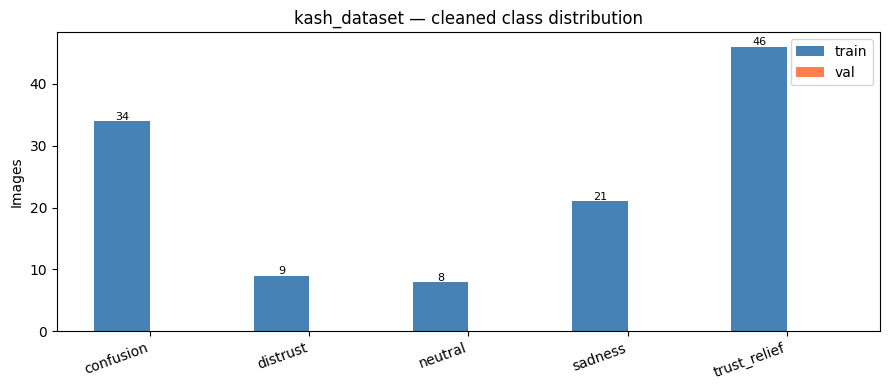


All outputs in: /Users/pv/Documents/STUDY/CODEprojects/project-1-emotion-aware-chatbot-team14/data/kash_clean
Next step: download labels.csv + images/ folder, re-upload as a Kaggle dataset, then run notebook 6.


In [33]:
counts_by_split = accepted_df.groupby(['label_name', 'split']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(counts_by_split))
w = 0.35
bars_t = ax.bar(x - w/2, counts_by_split.get('train', 0), w, label='train', color='steelblue')
bars_v = ax.bar(x + w/2, counts_by_split.get('val',   0), w, label='val',   color='coral')

for bar in list(bars_t) + list(bars_v):
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, str(int(h)), ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(counts_by_split.index, rotation=20, ha='right')
ax.set_ylabel('Images')
ax.set_title('kash_dataset — cleaned class distribution')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'summary.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nAll outputs in: {OUT_DIR}')
print('Next step: download labels.csv + images/ folder, re-upload as a Kaggle dataset, then run notebook 6.')